## Measuring dependency between data

Given a real dataset with two columns, "Height" vs "Weight", our objective is to establish whether a dependence relationship exists. We'll compute:

- Pearson coefficient
- Spearman coefficient
- Kendal coefficient
- Distance correlation

In [1]:
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
from dcor import distance_stats # dcor external library for distance metrics
from dcor.independence import distance_correlation_t_test # t-test for stance correlation
import numpy as np
from scipy.stats import pearsonr, spearmanr, kendalltau, t, rankdata # Pearson, Spearman and Kendal coefficients and t-tests

In [2]:
dataset = pd.read_csv('SOCR-HeightWeight.csv') # Loading the dataset
dataset.drop( # Index column dropped
    columns = 'Index',
    inplace = True
)
dataset

,Height(Inches),Weight(Pounds)
0,65.78331,112.9925
1,71.51521,136.4873
2,69.39874,153.0269
3,68.21660,142.3354
4,67.78781,144.2971
...,...,...
24995,69.50215,118.0312
24996,64.54826,120.1932
24997,64.69855,118.2655
24998,67.52918,132.2682


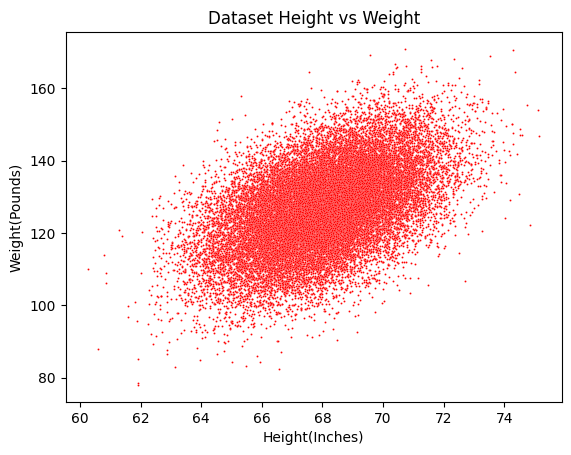

In [3]:
sb.scatterplot( # Scatter visualization
    data = dataset,
    x = 'Height(Inches)',
    y = 'Weight(Pounds)',
    s = 2,
    color = 'red')
plt.title('Dataset Height vs Weight')
plt.show()

By visualization, we can see the presence of a linear relationship. We can measure it through the linear correlation coefficient (Pearson's coefficient):

$$
    r = \frac{\operatorname{Cov}(H, \, W)}{\operatorname{Std}(H) \, \operatorname{Std}(W)} \qquad -1 \leq r \leq 1
$$

We expect at least $r \gt 0$

In [4]:
height = dataset['Height(Inches)'] # Pandas DataFrame one-dimensional
height_np = dataset['Height(Inches)'].to_numpy() # Numpy array one-dimensional
weight = dataset['Weight(Pounds)']
weight_np = dataset['Weight(Pounds)'].to_numpy()

In [5]:
r = height.corr( # Linear correlation coefficient (Pearson) by Pandas
    weight,
    method = 'pearson'
)
r

np.float64(0.5028585206028438)

$r \approx 0.5$ indicates that the linear relationship could exist. To be sure, we can perform some tests related to Pearson coefficient.
Under the following assumptions:

- $H$ and $W$ are random variables normally distributed
- All pairs ($H$, $W$) are independent and identically distributed
- Homoscedasticity of the dataset

The following quantity:

$$
    \tilde{t} = r \, \sqrt{\frac{n_{\text{data}} - 2}{1 - r ^ 2}}
$$

Follows the t-distribution (or Student's distribution) with $n_{\text{data}} - 2$ degrees of freedom. If $P(t \geq \tilde{t}) < 0.05$, then a linear relationship between data truly exists.

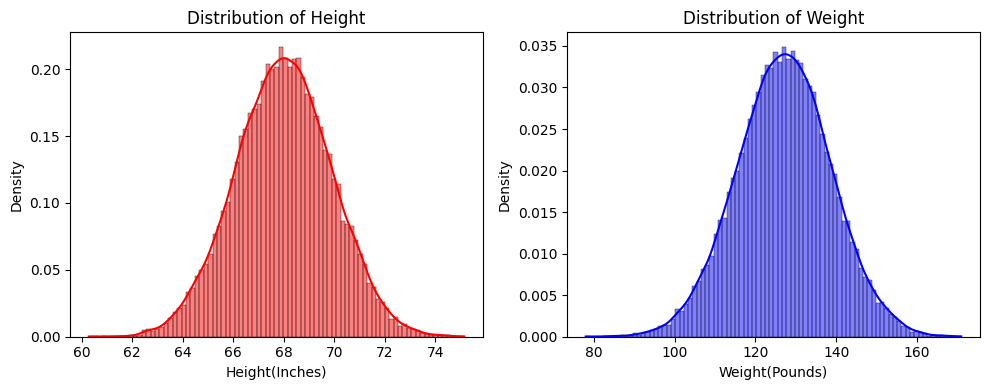

In [6]:
fig, axs = plt.subplots(1, 2, figsize = (10, 4)) # Histogram of data

sb.histplot( # Plot 1: Height histogram
    data = dataset,
    x = 'Height(Inches)',
    stat = 'density',
    bins = 'auto',
    kde = True,
    color = 'red',
    ax = axs[0]
)
axs[0].set_title('Distribution of Height')

sb.histplot( # Plot 2: Weight histogram
    data = dataset,
    x = 'Weight(Pounds)',
    stat = 'density',
    bins = 'auto',
    kde =True,
    color = 'blue',
    ax = axs[1]
)
axs[1].set_title('Distribution of Weight')

plt.tight_layout()
plt.show()

t-test assumptions are satisfied. We can proceed over

In [7]:
pearsonr( # Pearson coefficient and p-value by SciPy
    x = height_np,
    y = weight_np,
    alternative = 'two-sided'
)

PearsonRResult(statistic=np.float64(0.502858520602844), pvalue=np.float64(0.0))

We can perform the test "manually" as shown

In [8]:
df = len(weight_np) - 2 # Degrees of freedom
threshold = r * np.sqrt(df / (1 - r ** 2)) # tilde t
threshold

np.float64(91.98126881740797)

In [9]:
x = np.linspace(threshold - 50, threshold + 50, 100)
t.pdf(x, df) # Probability density function around tilde t, with df degrees of freedom

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

We can easily see that the probability density function of $t$ is identically zero around $\tilde{t}$. So the area under the curve for $t \geq \tilde{t}$ (p-value) is zero. So, a moderate linear relationship does exist between data

Another good metric is the Spearman's rank correlation coefficient. While Pearson's coefficient measures the strength and direction of linear relationships between data, Spearman's coefficient is more general and measures the strength and direction of monotonic relationships between data. It is defined exactly as the Pearson's coefficient, but with data ranks or fractional ranks instead of raw data

In [10]:
height.corr( # Spearman's coefficient by Pandas
    weight,
    method = 'spearman'
)

np.float64(0.487034975354053)

We can compute it "manually" as shown

In [11]:
height_rank, weight_rank = rankdata( # Ranking the dataset
    a = height_np,
    method = 'average'
), rankdata(
    a = weight_np,
    method = 'average'
)
height_rank, weight_rank

(array([ 3084., 24234., 19255., ...,  1096., 10089., 16970.],
       shape=(25000,)),
 array([ 2836., 19818., 24667., ...,  5574., 16760., 10580.],
       shape=(25000,)))

In [12]:
np.corrcoef(height_rank, weight_rank) # Pearson correlation matrix of ranks

array([[1.        , 0.48703498],
       [0.48703498, 1.        ]])

This results indicates a moderate positive monotonic relationship: when height increases, weight tends to increase as well. As done before, we can perform a similar t-test for Spearman's coefficient

In [13]:
spearmanr( # Spearman coefficient and p-value by SciPy
    a = height_np,
    b = weight_np,
    alternative = 'two-sided'
)

SignificanceResult(statistic=np.float64(0.487034975354053), pvalue=np.float64(0.0))

Another useful metric is the Kendall $\tau$ coefficient, which measures the strength and direction of monotonic relationships using a different approach than Spearman's

In [14]:
height.corr( # Kendall tau-b coefficient by Pandas
    weight,
    method = 'kendall'
)

np.float64(0.33624236390498347)

In [15]:
kendalltau( # Kendall tau-b coefficient and p-value by SciPy
    x = height_np,
    y = weight_np,
    method = 'auto',
    variant = 'b',
    alternative = 'two-sided'
)

SignificanceResult(statistic=np.float64(0.33624236390498347), pvalue=np.float64(0.0))

To detect any kind of dependency between Height and Weight (linear, non-linear, non-monotonic...), we can compute some distance metrics: distance covariance and distance correlation. In particular, if the distance correlation is zero than data are fully statistically independent. We can also perform a t-test as shown below

In [16]:
distance_stats( # Distance covariance , distance correlation, height distance variance, weight distance variance by dcor package
    x = height_np,
    y = weight_np,
    method = 'auto'
)

Stats(covariance_xy=np.float64(1.3652425491175606), correlation_xy=np.float64(0.4582723008797339), variance_x=np.float64(1.2063240306655512), variance_y=np.float64(7.357130072776704))

In [17]:
distance_correlation_t_test( # t-test of distance correlation by dcor package
    x = height_np,
    y = weight_np
)

HypothesisTest(pvalue=np.float64(0.0), statistic=np.float64(3795.066676607333))

The distance correlation detects a moderate relationship between data, but it does not tell us what kind of relationship it is